# Final Model Comparison

This notebook evaluates and visualizes test-set performance for:

- MPNet SentenceTransformer with the original/unretrained encoder
- MPNet SentenceTransformer with the retrained encoder
- TF-IDF + One-vs-Rest Logistic Regression



## 1. Setup


In [78]:
from pathlib import Path
import json
import time
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
)
from sentence_transformers import SentenceTransformer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", 80)


In [79]:
def find_project_root(start: Path | None = None) -> Path:
    path = (start or Path.cwd()).resolve()
    for candidate in [path, *path.parents]:
        if (
            (candidate / "data" / "Restaurant_ABSA_processed.csv").exists()
            and (candidate / "outputs" / "MPNet" / "data_split.npz").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "Restaurant_ABSA_processed.csv"
SPLIT_PATH = PROJECT_ROOT / "outputs" / "MPNet" / "data_split.npz"

MPNet_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "MPNet"
MPNet_MODEL_DIR = PROJECT_ROOT / "models" / "mpnet"
MPNet_CLASSIFIER_DIR = MPNet_MODEL_DIR / "classifiers"

TFIDF_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "TF-IDF"
TFIDF_MODEL_DIR = PROJECT_ROOT / "models" / "TF-IDF"
TFIDF_CLASSIFIER_DIR = TFIDF_MODEL_DIR / "classifiers"

FINAL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "final_comparison"
FINAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ASPECT_COLUMNS = ["food", "price", "service", "ambiance", "miscellaneous"]
TFIDF_ASPECT_COLUMNS = ["food", "service", "price", "ambiance", "miscellaneous"]

required_paths = [
    DATA_PATH,
    SPLIT_PATH,
    MPNet_CLASSIFIER_DIR / "unretrained" / "model.joblib",
    MPNet_CLASSIFIER_DIR / "unretrained" / "metadata.json",
    MPNet_CLASSIFIER_DIR / "retrained" / "model.joblib",
    MPNet_CLASSIFIER_DIR / "retrained" / "metadata.json",
    TFIDF_OUTPUT_DIR / "X_test_tfidf.npz",
    TFIDF_CLASSIFIER_DIR / "tfidf_ovr_logreg.joblib",
    TFIDF_CLASSIFIER_DIR / "tfidf_metadata.json",
]

missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing required artifacts:\n" + "\n".join(map(str, missing_paths)))

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Final outputs:", FINAL_OUTPUT_DIR)


Project root: D:\ZB\Code\UIT\CS221
Final outputs: D:\ZB\Code\UIT\CS221\outputs\final_comparison


## 2. Load Test Set


In [80]:
df = pd.read_csv(DATA_PATH).dropna(subset=["review_en"]).reset_index(drop=True)
split = np.load(SPLIT_PATH)
test_idx = split["test_idx"]

test_df = df.iloc[test_idx].copy().reset_index().rename(columns={"index": "source_row"})
test_texts = test_df["review_en"].astype(str).tolist()
y_test = test_df[ASPECT_COLUMNS].to_numpy(dtype=np.int8)

print(f"Test samples: {len(test_df)}")
display(test_df[["source_row", "review_en", *ASPECT_COLUMNS]].head())


Test samples: 160


,source_row,review_en,food,price,service,ambiance,miscellaneous
0,692,although the price of the product has increased the quality and taste have not changed,1,1,0,0,0
1,779,the restaurant is very clean and the ambience is very nice,0,0,0,1,0
2,63,the side dishes are not very good but the service is good,1,0,1,0,0
3,532,from today it is my favorite restaurant because the service here is very bad and the price of everything is very high,0,1,1,0,0
4,66,best chicken pressure the price of 120 rupees seemed right to me,1,1,0,0,0


## 3. Shared Evaluation Helpers


In [81]:
def labels_to_text(row, aspect_cols=ASPECT_COLUMNS) -> str:
    row = np.asarray(row).astype(bool)
    labels = np.array(aspect_cols)[row]
    return ", ".join(labels) if len(labels) else "None"


def apply_thresholds(probabilities: np.ndarray, thresholds: dict, aspect_cols: list[str]) -> np.ndarray:
    predictions = np.zeros_like(probabilities, dtype=np.int8)
    for index, aspect in enumerate(aspect_cols):
        predictions[:, index] = (probabilities[:, index] >= thresholds[aspect]).astype(np.int8)

    empty_rows = np.flatnonzero(predictions.sum(axis=1) == 0)
    for row in empty_rows:
        predictions[row, np.argmax(probabilities[row])] = 1
    return predictions


def reorder_columns(matrix: np.ndarray, from_cols: list[str], to_cols: list[str]) -> np.ndarray:
    positions = [from_cols.index(col) for col in to_cols]
    return matrix[:, positions]


def evaluate_predictions(model_name: str, y_true: np.ndarray, y_pred: np.ndarray, seconds: float | None = None) -> dict:
    per_aspect_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    metrics = {
        "model": model_name,
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "samples_f1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "precision_micro": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "recall_micro": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "exact_match_ratio": accuracy_score(y_true, y_pred),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "mean_predicted_labels": y_pred.sum(axis=1).mean(),
        "mean_true_labels": y_true.sum(axis=1).mean(),
    }
    if seconds is not None:
        metrics["seconds"] = seconds
        metrics["milliseconds_per_review"] = seconds * 1000 / len(y_true)

    for index, aspect in enumerate(ASPECT_COLUMNS):
        metrics[f"{aspect}_f1"] = per_aspect_f1[index]
    return metrics


def build_prediction_frame(model_name: str, probabilities: np.ndarray, predictions: np.ndarray) -> pd.DataFrame:
    output = test_df[["source_row", "review_en", "review_cleaned"]].copy()
    output["model"] = model_name
    output["true_aspects"] = [labels_to_text(row) for row in y_test]
    output["predicted_aspects"] = [labels_to_text(row) for row in predictions]
    output["exact_match"] = (predictions == y_test).all(axis=1)
    output["true_label_count"] = y_test.sum(axis=1)
    output["predicted_label_count"] = predictions.sum(axis=1)

    for index, aspect in enumerate(ASPECT_COLUMNS):
        output[f"true_{aspect}"] = y_test[:, index]
        output[f"pred_{aspect}"] = predictions[:, index]
        output[f"prob_{aspect}"] = probabilities[:, index]

    output["max_probability"] = probabilities.max(axis=1)
    output["mean_true_aspect_probability"] = [
        probabilities[row_index, y_test[row_index].astype(bool)].mean()
        if y_test[row_index].any()
        else np.nan
        for row_index in range(len(y_test))
    ]
    return output


## 4. Evaluate MPNet Models


In [82]:
def evaluate_mpnet_bundle(bundle_name: str) -> dict:
    bundle_dir = MPNet_CLASSIFIER_DIR / bundle_name
    classifier = joblib.load(bundle_dir / "model.joblib")
    with (bundle_dir / "metadata.json").open(encoding="utf-8") as file:
        metadata = json.load(file)

    aspect_cols = metadata["aspect_cols"]
    encoder_path = PROJECT_ROOT / metadata["encoder_path"]
    encoder = SentenceTransformer(str(encoder_path))

    start = time.perf_counter()
    embeddings = encoder.encode(
        test_texts,
        batch_size=metadata.get("batch_size", 32),
        normalize_embeddings=metadata.get("normalize_embeddings", True),
        convert_to_numpy=True,
        show_progress_bar=True,
    )
    probabilities = classifier.predict_proba(embeddings)
    seconds = time.perf_counter() - start

    predictions = apply_thresholds(probabilities, metadata["thresholds"], aspect_cols)
    probabilities = reorder_columns(probabilities, aspect_cols, ASPECT_COLUMNS)
    predictions = reorder_columns(predictions, aspect_cols, ASPECT_COLUMNS)

    model_name = f"MPNet {bundle_name}"
    return {
        "model_name": model_name,
        "metadata": metadata,
        "probabilities": probabilities,
        "predictions": predictions,
        "metrics": evaluate_predictions(model_name, y_test, predictions, seconds=seconds),
        "report": classification_report(
            y_test,
            predictions,
            target_names=ASPECT_COLUMNS,
            output_dict=True,
            zero_division=0,
        ),
        "prediction_frame": build_prediction_frame(model_name, probabilities, predictions),
    }


mpnet_results = {
    "MPNet unretrained": evaluate_mpnet_bundle("unretrained"),
    "MPNet retrained": evaluate_mpnet_bundle("retrained"),
}


Batches: 100%|██████████| 5/5 [00:04<00:00,  1.02it/s]


## 5. Evaluate TF-IDF Model


In [83]:
def evaluate_tfidf_model() -> dict:
    X_test_tfidf = sp.load_npz(TFIDF_OUTPUT_DIR / "X_test_tfidf.npz")
    classifier = joblib.load(TFIDF_CLASSIFIER_DIR / "tfidf_ovr_logreg.joblib")
    with (TFIDF_CLASSIFIER_DIR / "tfidf_metadata.json").open(encoding="utf-8") as file:
        metadata = json.load(file)

    start = time.perf_counter()
    probabilities = classifier.predict_proba(X_test_tfidf)
    seconds = time.perf_counter() - start

    predictions = apply_thresholds(probabilities, metadata["thresholds"], TFIDF_ASPECT_COLUMNS)
    probabilities = reorder_columns(probabilities, TFIDF_ASPECT_COLUMNS, ASPECT_COLUMNS)
    predictions = reorder_columns(predictions, TFIDF_ASPECT_COLUMNS, ASPECT_COLUMNS)

    model_name = "TF-IDF"
    return {
        "model_name": model_name,
        "metadata": metadata,
        "probabilities": probabilities,
        "predictions": predictions,
        "metrics": evaluate_predictions(model_name, y_test, predictions, seconds=seconds),
        "report": classification_report(
            y_test,
            predictions,
            target_names=ASPECT_COLUMNS,
            output_dict=True,
            zero_division=0,
        ),
        "prediction_frame": build_prediction_frame(model_name, probabilities, predictions),
    }


tfidf_result = evaluate_tfidf_model()
all_results = {**mpnet_results, "TF-IDF": tfidf_result}


## 6. Overall Metrics


In [84]:
comparison_df = (
    pd.DataFrame([result["metrics"] for result in all_results.values()])
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

comparison_df.to_csv(FINAL_OUTPUT_DIR / "final_model_comparison.csv", index=False)
display(comparison_df)


,model,macro_f1,micro_f1,samples_f1,precision_micro,recall_micro,exact_match_ratio,hamming_loss,mean_predicted_labels,mean_true_labels,seconds,milliseconds_per_review,food_f1,price_f1,service_f1,ambiance_f1,miscellaneous_f1
0,MPNet retrained,0.811839,0.909091,0.909167,0.870206,0.951613,0.71250,0.07375,2.11875,1.9375,4.930697,30.816857,0.964029,1.000000,0.913580,0.985507,0.196078
1,TF-IDF,0.773408,0.872274,0.870417,0.843373,0.903226,0.63750,0.10250,2.07500,1.9375,0.003323,0.020771,0.911565,0.918605,0.829268,0.763158,0.444444
2,MPNet unretrained,0.710986,0.832817,0.834375,0.800595,0.867742,0.54375,0.13500,2.10000,1.9375,3.246404,20.290028,0.925795,0.937143,0.705882,0.694444,0.291667


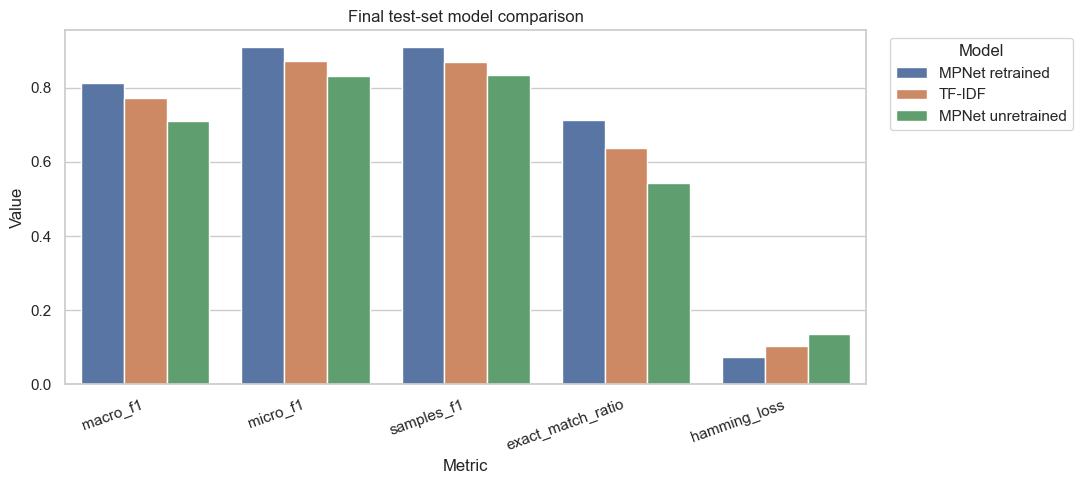

In [85]:
main_metrics = [
    "macro_f1",
    "micro_f1",
    "samples_f1",
    "exact_match_ratio",
    "hamming_loss",
]

plot_df = comparison_df.melt(
    id_vars="model",
    value_vars=main_metrics,
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="metric", y="value", hue="model")
plt.title("Final test-set model comparison")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "overall_metrics_comparison.png", dpi=160)
plt.show()


,model,seconds,milliseconds_per_review
0,MPNet retrained,4.930697,30.816857
1,TF-IDF,0.003323,0.020771
2,MPNet unretrained,3.246404,20.290028


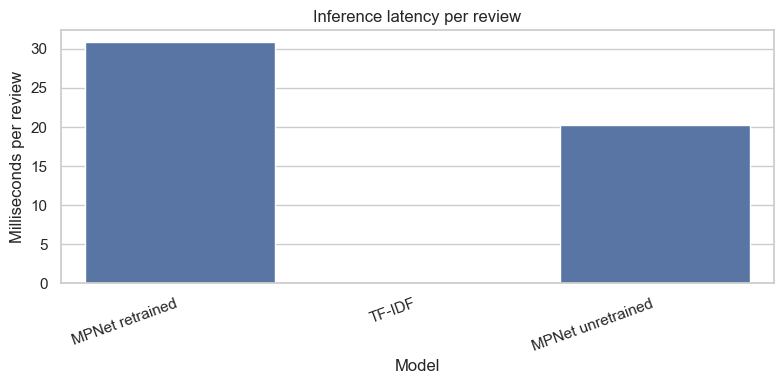

In [86]:
speed_cols = ["model", "seconds", "milliseconds_per_review"]
speed_df = comparison_df[[col for col in speed_cols if col in comparison_df.columns]].copy()
display(speed_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=speed_df, x="model", y="milliseconds_per_review")
plt.title("Inference latency per review")
plt.xlabel("Model")
plt.ylabel("Milliseconds per review")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "latency_comparison.png", dpi=160)
plt.show()


## 7. Per-Aspect F1 Comparison


model,MPNet retrained,MPNet unretrained,TF-IDF
aspect,,,
food,0.964029,0.925795,0.911565
price,1.000000,0.937143,0.918605
service,0.913580,0.705882,0.829268
ambiance,0.985507,0.694444,0.763158
miscellaneous,0.196078,0.291667,0.444444


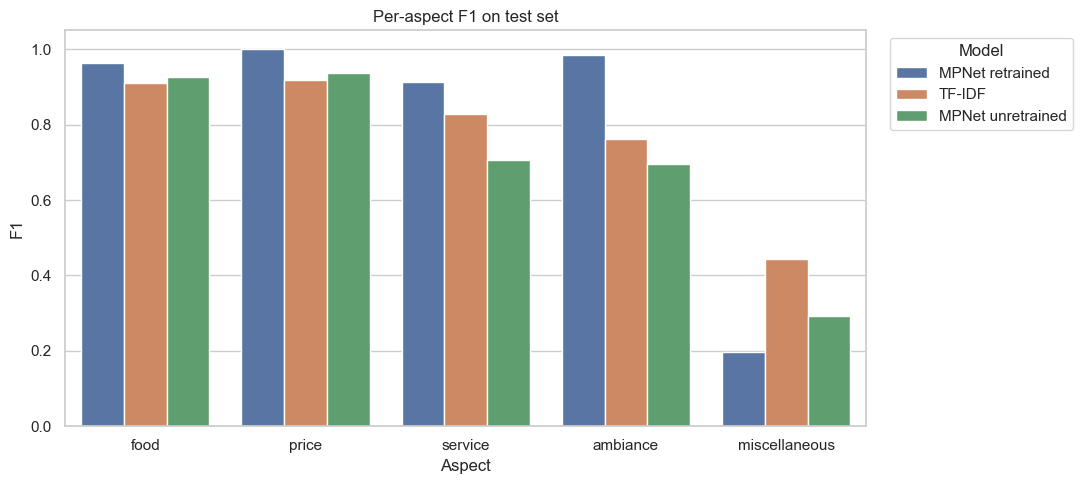

In [87]:
aspect_f1_cols = [f"{aspect}_f1" for aspect in ASPECT_COLUMNS]
aspect_f1_df = comparison_df[["model", *aspect_f1_cols]].melt(
    id_vars="model",
    var_name="aspect",
    value_name="f1",
)
aspect_f1_df["aspect"] = aspect_f1_df["aspect"].str.replace("_f1", "", regex=False)

aspect_f1_df.to_csv(FINAL_OUTPUT_DIR / "per_aspect_f1_comparison.csv", index=False)
display(aspect_f1_df.pivot(index="aspect", columns="model", values="f1").loc[ASPECT_COLUMNS])

plt.figure(figsize=(11, 5))
sns.barplot(data=aspect_f1_df, x="aspect", y="f1", hue="model")
plt.title("Per-aspect F1 on test set")
plt.xlabel("Aspect")
plt.ylabel("F1")
plt.ylim(0, 1.05)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "per_aspect_f1_comparison.png", dpi=160)
plt.show()


## 8. Classification Reports


In [88]:
report_frames = []
for model_name, result in all_results.items():
    report = pd.DataFrame(result["report"]).T.reset_index().rename(columns={"index": "label"})
    report.insert(0, "model", model_name)
    report_frames.append(report)

reports_df = pd.concat(report_frames, ignore_index=True)
reports_df.to_csv(FINAL_OUTPUT_DIR / "classification_reports.csv", index=False)

display(
    reports_df[
        reports_df["label"].isin(ASPECT_COLUMNS + ["micro avg", "macro avg", "samples avg"])
    ].round(4)
)


,model,label,precision,recall,f1-score,support
0,MPNet unretrained,food,0.8792,0.9776,0.9258,134.0
1,MPNet unretrained,price,0.9111,0.9647,0.9371,85.0
2,MPNet unretrained,service,0.9231,0.5714,0.7059,42.0
3,MPNet unretrained,ambiance,0.6757,0.7143,0.6944,35.0
4,MPNet unretrained,miscellaneous,0.2059,0.5000,0.2917,14.0
5,MPNet unretrained,micro avg,0.8006,0.8677,0.8328,310.0
6,MPNet unretrained,macro avg,0.7190,0.7456,0.7110,310.0
8,MPNet unretrained,samples avg,0.8417,0.8729,0.8344,310.0
9,MPNet retrained,food,0.9306,1.0000,0.9640,134.0
10,MPNet retrained,price,1.0000,1.0000,1.0000,85.0


## 9. Confusion Matrices


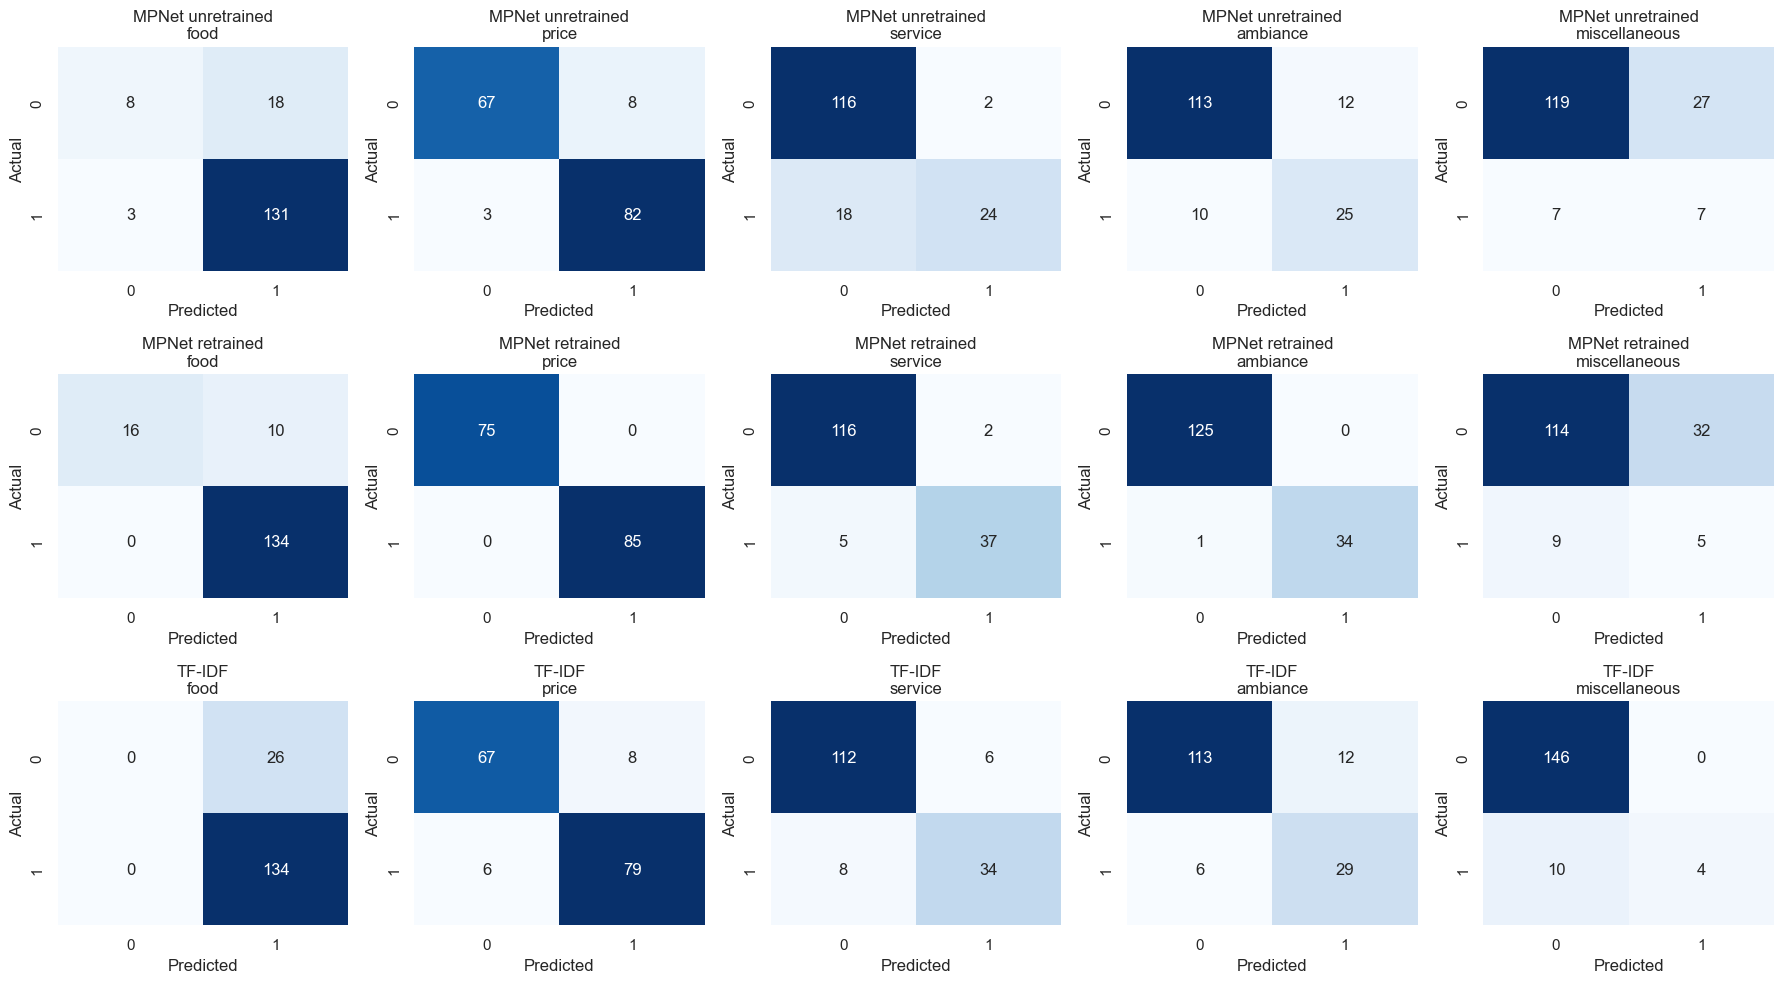

In [89]:
fig, axes = plt.subplots(len(all_results), len(ASPECT_COLUMNS), figsize=(18, 10))

for row_index, (model_name, result) in enumerate(all_results.items()):
    matrices = multilabel_confusion_matrix(y_test, result["predictions"])
    for col_index, aspect in enumerate(ASPECT_COLUMNS):
        ax = axes[row_index, col_index]
        sns.heatmap(
            matrices[col_index],
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax,
        )
        ax.set_title(f"{model_name}\n{aspect}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "confusion_matrices.png", dpi=160)
plt.show()


## 10. Exact-Match Overlap


In [90]:
exact_match_df = test_df[["source_row", "review_en", "review_cleaned"]].copy()
exact_match_df["true_aspects"] = [labels_to_text(row) for row in y_test]

for model_name, result in all_results.items():
    key = model_name.lower().replace(" ", "_").replace("-", "")
    exact_match_df[f"{key}_predicted_aspects"] = [
        labels_to_text(row) for row in result["predictions"]
    ]
    exact_match_df[f"{key}_exact_match"] = (
        result["predictions"] == y_test
    ).all(axis=1)

exact_match_cols = [col for col in exact_match_df.columns if col.endswith("_exact_match")]
overlap_summary = (
    exact_match_df[exact_match_cols]
    .value_counts()
    .rename_axis(exact_match_cols)
    .reset_index(name="sample_count")
)

exact_match_df.to_csv(FINAL_OUTPUT_DIR / "sample_level_predictions.csv", index=False)
overlap_summary.to_csv(FINAL_OUTPUT_DIR / "exact_match_overlap_summary.csv", index=False)

display(overlap_summary)


,mpnet_unretrained_exact_match,mpnet_retrained_exact_match,tfidf_exact_match,sample_count
0,True,True,True,73
1,False,False,False,32
2,False,True,True,19
3,False,True,False,14
4,True,True,False,8
5,False,False,True,8
6,True,False,False,4
7,True,False,True,2


## 11. Samples Correct In MPNet But Wrong In TF-IDF


In [91]:
mpnet_key = "mpnet_retrained"
tfidf_key = "tfidf"

mpnet_correct_tfidf_wrong = exact_match_df[
    exact_match_df[f"{mpnet_key}_exact_match"]
    & ~exact_match_df[f"{tfidf_key}_exact_match"]
].copy()

tfidf_correct_mpnet_wrong = exact_match_df[
    ~exact_match_df[f"{mpnet_key}_exact_match"]
    & exact_match_df[f"{tfidf_key}_exact_match"]
].copy()

comparison_sample_cols = [
    "source_row",
    "review_en",
    "true_aspects",
    f"{mpnet_key}_predicted_aspects",
    f"{tfidf_key}_predicted_aspects",
]

mpnet_correct_tfidf_wrong[comparison_sample_cols].to_csv(
    FINAL_OUTPUT_DIR / "mpnet_retrained_correct_tfidf_wrong.csv",
    index=False,
)
tfidf_correct_mpnet_wrong[comparison_sample_cols].to_csv(
    FINAL_OUTPUT_DIR / "tfidf_correct_mpnet_retrained_wrong.csv",
    index=False,
)

print(f"MPNet retrained correct, TF-IDF wrong: {len(mpnet_correct_tfidf_wrong)}")
display(mpnet_correct_tfidf_wrong[comparison_sample_cols].head(20))


MPNet retrained correct, TF-IDF wrong: 22


,source_row,review_en,true_aspects,mpnet_retrained_predicted_aspects,tfidf_predicted_aspects
9,625,their kitchen is not very nice so people cannot enjoy the taste of the food as much,"food, ambiance","food, ambiance",food
10,65,their service is great and food quality is good,"food, service","food, service","food, service, ambiance"
16,244,it was understood that the less expensive food can be good but eating the food of this restaurant,"food, price","food, price","food, ambiance"
18,744,there was not the chutney it was supposed to be but that did not matter because it was free anyway,"food, price","food, price",food
29,772,the food is of good quality and reasonably priced,"food, price","food, price",food
46,422,although the quality of the food was not the best and the environment was not that bad,"food, ambiance","food, ambiance","food, service, ambiance"
51,109,the location of the restaurant is good and the price of the food is also low,"price, miscellaneous","price, miscellaneous","food, price, miscellaneous"
52,662,the food tastes great and the service is great,"food, service","food, service","food, service, ambiance"
61,473,every item tasted amazing and their workmanship was better than other places,"food, service","food, service","food, ambiance"
62,652,haleem was amazing in one word i became a fan,"food, miscellaneous","food, miscellaneous","food, price, miscellaneous"


In [92]:
print(f"TF-IDF correct, MPNet retrained wrong: {len(tfidf_correct_mpnet_wrong)}")
display(tfidf_correct_mpnet_wrong[comparison_sample_cols].head(20))


TF-IDF correct, MPNet retrained wrong: 10


,source_row,review_en,true_aspects,mpnet_retrained_predicted_aspects,tfidf_predicted_aspects
12,634,schizlingter is a type of food that is served hot and fresh,"food, service","food, miscellaneous","food, service"
13,67,food taste great interior is good,"food, ambiance","food, ambiance, miscellaneous","food, ambiance"
21,533,the taste of ice cream is still on my tongue i was so excited but the environment of their shop was very bad,"food, ambiance","food, ambiance, miscellaneous","food, ambiance"
55,367,the taste of the sushi was not that great but the atmosphere of the restaurant was so good that i would go there again,"food, ambiance","food, ambiance, miscellaneous","food, ambiance"
60,490,halim is very strict but i disliked the cleanliness aspect,"food, ambiance","food, ambiance, miscellaneous","food, ambiance"
66,49,disgusting halim and the environment is dirty,"food, ambiance","food, ambiance, miscellaneous","food, ambiance"
69,86,there are many items in the same price range that are good and the environment is also fair,"food, price, ambiance","food, price","food, price, ambiance"
74,31,as for the beef the test was very good but the name kalabuna was not right,food,"food, miscellaneous",food
123,715,nanroti contains a lot of butter which makes the bread taste better but the place where the bread is made is not clean,"food, ambiance","food, ambiance, miscellaneous","food, ambiance"
130,658,nehari is very attractive but the environment is not very nice,"food, ambiance","food, ambiance, miscellaneous","food, ambiance"


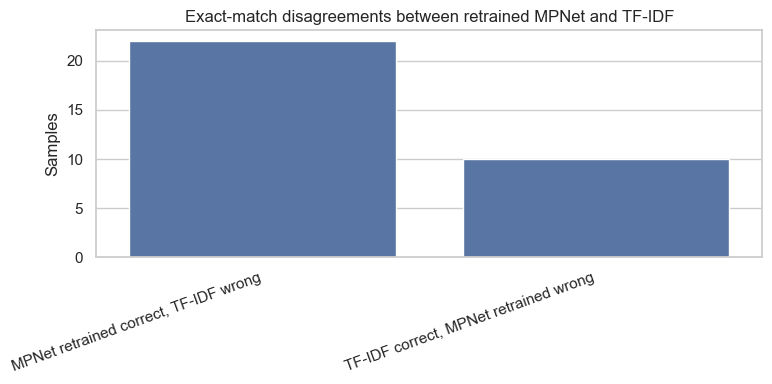

,case,sample_count
0,"MPNet retrained correct, TF-IDF wrong",22
1,"TF-IDF correct, MPNet retrained wrong",10


In [93]:
counts = pd.DataFrame(
    {
        "case": [
            "MPNet retrained correct, TF-IDF wrong",
            "TF-IDF correct, MPNet retrained wrong",
        ],
        "sample_count": [
            len(mpnet_correct_tfidf_wrong),
            len(tfidf_correct_mpnet_wrong),
        ],
    }
)

plt.figure(figsize=(8, 4))
sns.barplot(data=counts, x="case", y="sample_count")
plt.title("Exact-match disagreements between retrained MPNet and TF-IDF")
plt.xlabel("")
plt.ylabel("Samples")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "mpnet_tfidf_disagreement_counts.png", dpi=160)
plt.show()

display(counts)


## 12. Aspect-Level Error Differences


In [94]:
error_rows = []
for model_name, result in all_results.items():
    predictions = result["predictions"]
    for index, aspect in enumerate(ASPECT_COLUMNS):
        y_true_col = y_test[:, index]
        y_pred_col = predictions[:, index]
        false_positive = int(((y_true_col == 0) & (y_pred_col == 1)).sum())
        false_negative = int(((y_true_col == 1) & (y_pred_col == 0)).sum())
        true_positive = int(((y_true_col == 1) & (y_pred_col == 1)).sum())
        true_negative = int(((y_true_col == 0) & (y_pred_col == 0)).sum())
        error_rows.append(
            {
                "model": model_name,
                "aspect": aspect,
                "true_positive": true_positive,
                "false_positive": false_positive,
                "false_negative": false_negative,
                "true_negative": true_negative,
            }
        )

error_df = pd.DataFrame(error_rows)
error_df.to_csv(FINAL_OUTPUT_DIR / "aspect_error_counts.csv", index=False)
display(error_df)


,model,aspect,true_positive,false_positive,false_negative,true_negative
0,MPNet unretrained,food,131,18,3,8
1,MPNet unretrained,price,82,8,3,67
2,MPNet unretrained,service,24,2,18,116
3,MPNet unretrained,ambiance,25,12,10,113
4,MPNet unretrained,miscellaneous,7,27,7,119
5,MPNet retrained,food,134,10,0,16
6,MPNet retrained,price,85,0,0,75
7,MPNet retrained,service,37,2,5,116
8,MPNet retrained,ambiance,34,0,1,125
9,MPNet retrained,miscellaneous,5,32,9,114


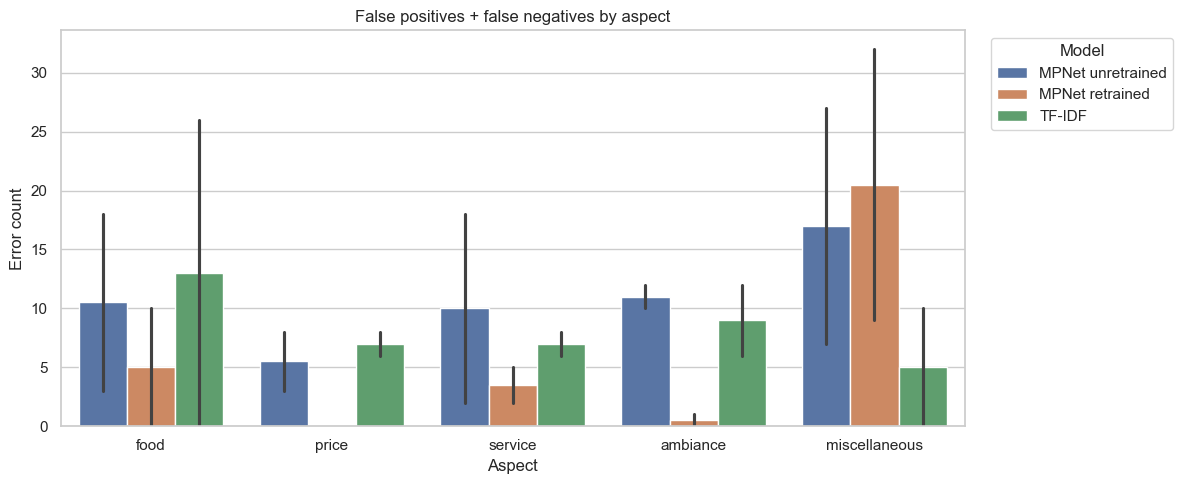

In [95]:
error_plot_df = error_df.melt(
    id_vars=["model", "aspect"],
    value_vars=["false_positive", "false_negative"],
    var_name="error_type",
    value_name="count",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=error_plot_df, x="aspect", y="count", hue="model")
plt.title("False positives + false negatives by aspect")
plt.xlabel("Aspect")
plt.ylabel("Error count")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "aspect_total_error_comparison.png", dpi=160)
plt.show()


## 13. Best And Worst Cases

Best cases are exact-match samples where the model assigns high average probability to the true aspects.

Worst cases are non-exact-match samples ranked by:

1. more label errors first
2. higher wrong-confidence first
3. lower true-aspect confidence first

These tables are useful for explaining where each model is reliable and where it fails.


In [96]:
def aspect_list_from_binary(row: np.ndarray) -> list[str]:
    return [aspect for aspect, value in zip(ASPECT_COLUMNS, row.astype(int)) if value == 1]


def build_case_analysis_frame(model_name: str, result: dict) -> pd.DataFrame:
    probabilities = result["probabilities"]
    predictions = result["predictions"]

    rows = []
    for row_index in range(len(test_df)):
        true_row = y_test[row_index].astype(int)
        pred_row = predictions[row_index].astype(int)
        prob_row = probabilities[row_index]

        false_positive_aspects = [
            aspect
            for aspect_index, aspect in enumerate(ASPECT_COLUMNS)
            if true_row[aspect_index] == 0 and pred_row[aspect_index] == 1
        ]
        false_negative_aspects = [
            aspect
            for aspect_index, aspect in enumerate(ASPECT_COLUMNS)
            if true_row[aspect_index] == 1 and pred_row[aspect_index] == 0
        ]
        true_aspect_mask = true_row.astype(bool)
        predicted_aspect_mask = pred_row.astype(bool)
        wrong_predicted_mask = (true_row == 0) & (pred_row == 1)

        mean_true_probability = (
            float(prob_row[true_aspect_mask].mean())
            if true_aspect_mask.any()
            else np.nan
        )
        min_true_probability = (
            float(prob_row[true_aspect_mask].min())
            if true_aspect_mask.any()
            else np.nan
        )
        mean_predicted_probability = (
            float(prob_row[predicted_aspect_mask].mean())
            if predicted_aspect_mask.any()
            else np.nan
        )
        max_wrong_probability = (
            float(prob_row[wrong_predicted_mask].max())
            if wrong_predicted_mask.any()
            else 0.0
        )

        rows.append(
            {
                "model": model_name,
                "source_row": int(test_df.loc[row_index, "source_row"]),
                "review_en": test_df.loc[row_index, "review_en"],
                "true_aspects": labels_to_text(true_row),
                "predicted_aspects": labels_to_text(pred_row),
                "exact_match": bool((true_row == pred_row).all()),
                "label_error_count": int(np.abs(true_row - pred_row).sum()),
                "false_positive_aspects": ", ".join(false_positive_aspects) or "None",
                "false_negative_aspects": ", ".join(false_negative_aspects) or "None",
                "mean_true_probability": mean_true_probability,
                "min_true_probability": min_true_probability,
                "mean_predicted_probability": mean_predicted_probability,
                "max_wrong_probability": max_wrong_probability,
            }
        )

    return pd.DataFrame(rows)


case_frames = [
    build_case_analysis_frame(model_name, result)
    for model_name, result in all_results.items()
]
case_analysis_df = pd.concat(case_frames, ignore_index=True)
case_analysis_df.to_csv(FINAL_OUTPUT_DIR / "case_analysis_all_models.csv", index=False)

display(case_analysis_df.head())


,model,source_row,review_en,true_aspects,predicted_aspects,exact_match,label_error_count,false_positive_aspects,false_negative_aspects,mean_true_probability,min_true_probability,mean_predicted_probability,max_wrong_probability
0,MPNet unretrained,692,although the price of the product has increased the quality and taste have not changed,"food, price","food, price",True,0,None,None,0.545932,0.534758,0.545932,0.000000
1,MPNet unretrained,779,the restaurant is very clean and the ambience is very nice,ambiance,"ambiance, miscellaneous",False,1,miscellaneous,None,0.560718,0.560718,0.533389,0.506061
2,MPNet unretrained,63,the side dishes are not very good but the service is good,"food, service",food,False,1,None,service,0.518849,0.518235,0.518235,0.000000
3,MPNet unretrained,532,from today it is my favorite restaurant because the service here is very bad and the price of everything is very high,"price, service","food, miscellaneous",False,4,"food, miscellaneous","price, service",0.493210,0.479198,0.498096,0.501625
4,MPNet unretrained,66,best chicken pressure the price of 120 rupees seemed right to me,"food, price","food, price",True,0,None,None,0.561176,0.546307,0.561176,0.000000


In [97]:
best_case_frames = []
worst_case_frames = []

for model_name in all_results:
    model_cases = case_analysis_df[case_analysis_df["model"] == model_name].copy()

    best_cases = (
        model_cases[model_cases["exact_match"]]
        .sort_values(
            ["mean_true_probability", "min_true_probability"],
            ascending=[False, False],
        )
        .head(15)
    )
    worst_cases = (
        model_cases[~model_cases["exact_match"]]
        .sort_values(
            [
                "label_error_count",
                "max_wrong_probability",
                "mean_true_probability",
            ],
            ascending=[False, False, True],
        )
        .head(15)
    )

    safe_name = model_name.lower().replace(" ", "_").replace("-", "")
    best_cases.to_csv(FINAL_OUTPUT_DIR / f"{safe_name}_best_cases.csv", index=False)
    worst_cases.to_csv(FINAL_OUTPUT_DIR / f"{safe_name}_worst_cases.csv", index=False)

    best_case_frames.append(best_cases)
    worst_case_frames.append(worst_cases)

all_best_cases = pd.concat(best_case_frames, ignore_index=True)
all_worst_cases = pd.concat(worst_case_frames, ignore_index=True)

all_best_cases.to_csv(FINAL_OUTPUT_DIR / "best_cases_all_models.csv", index=False)
all_worst_cases.to_csv(FINAL_OUTPUT_DIR / "worst_cases_all_models.csv", index=False)

print("Saved best/worst case files to:", FINAL_OUTPUT_DIR)


Saved best/worst case files to: D:\ZB\Code\UIT\CS221\outputs\final_comparison


In [98]:
case_summary = (
    case_analysis_df
    .groupby("model")
    .agg(
        exact_matches=("exact_match", "sum"),
        total_samples=("exact_match", "size"),
        mean_label_errors=("label_error_count", "mean"),
        max_label_errors=("label_error_count", "max"),
        mean_true_probability=("mean_true_probability", "mean"),
        mean_predicted_probability=("mean_predicted_probability", "mean"),
        mean_max_wrong_probability=("max_wrong_probability", "mean"),
    )
    .reset_index()
)
case_summary["exact_match_ratio"] = (
    case_summary["exact_matches"] / case_summary["total_samples"]
)
case_summary.to_csv(FINAL_OUTPUT_DIR / "case_analysis_summary.csv", index=False)
display(case_summary.round(4))


,model,exact_matches,total_samples,mean_label_errors,max_label_errors,mean_true_probability,mean_predicted_probability,mean_max_wrong_probability,exact_match_ratio
0,MPNet retrained,114,160,0.3688,2,0.6205,0.6158,0.1366,0.7125
1,MPNet unretrained,87,160,0.6750,4,0.5298,0.5306,0.1686,0.5438
2,TF-IDF,102,160,0.5125,3,0.5001,0.5001,0.1531,0.6375


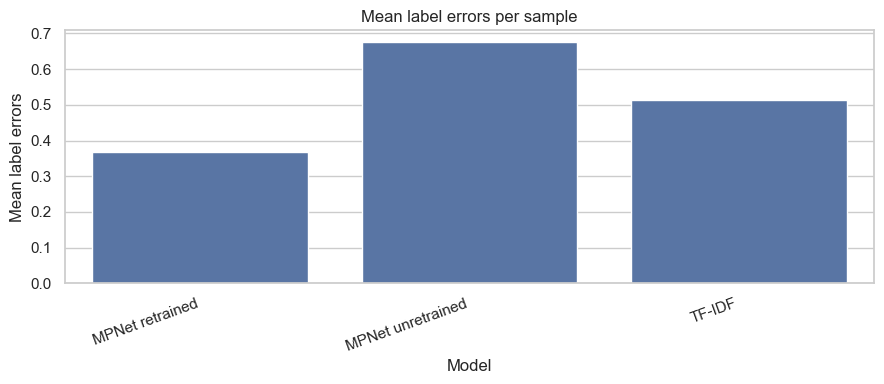

In [99]:
plt.figure(figsize=(9, 4))
sns.barplot(data=case_summary, x="model", y="mean_label_errors")
plt.title("Mean label errors per sample")
plt.xlabel("Model")
plt.ylabel("Mean label errors")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "mean_label_errors_by_model.png", dpi=160)
plt.show()


### Best cases by model


In [100]:
best_display_cols = [
    "model",
    "source_row",
    "review_en",
    "true_aspects",
    "predicted_aspects",
    "mean_true_probability",
    "min_true_probability",
]

display(
    all_best_cases[best_display_cols]
    .sort_values(["model", "mean_true_probability"], ascending=[True, False])
    .groupby("model")
    .head(8)
    .round(4)
)


,model,source_row,review_en,true_aspects,predicted_aspects,mean_true_probability,min_true_probability
15,MPNet retrained,628,it is usually a little less salty than other dishes the taste is unmatched,food,food,0.6706,0.6706
16,MPNet retrained,314,the price of hilsa fish tail filling was also low and the taste was decent,"food, price","food, price",0.6605,0.6461
17,MPNet retrained,204,the taste of kachchi is really unforgettable but the price is very high,"food, price","food, price",0.6592,0.6421
18,MPNet retrained,356,the price of the food is high but the quality of the food is not so good,"food, price","food, price",0.6592,0.6380
19,MPNet retrained,548,there is no sweetness in the laddu bro and the price is so high that i am disappointed,"food, price","food, price",0.6590,0.6388
20,MPNet retrained,692,although the price of the product has increased the quality and taste have not changed,"food, price","food, price",0.6589,0.6383
21,MPNet retrained,81,ilhasvajata is the same and the price is affordable,"food, price","food, price",0.6589,0.6403
22,MPNet retrained,434,there was nothing sweet about lachchi and the price was too expensive,"food, price","food, price",0.6588,0.6483
0,MPNet unretrained,204,the taste of kachchi is really unforgettable but the price is very high,"food, price","food, price",0.5712,0.5607
1,MPNet unretrained,101,chicken corn soup is just chicken and corn and the price is not that high,"food, price","food, price",0.5674,0.5576


### Worst cases by model


In [101]:
worst_display_cols = [
    "model",
    "source_row",
    "review_en",
    "true_aspects",
    "predicted_aspects",
    "label_error_count",
    "false_positive_aspects",
    "false_negative_aspects",
    "max_wrong_probability",
    "mean_true_probability",
]

display(
    all_worst_cases[worst_display_cols]
    .sort_values(
        ["model", "label_error_count", "max_wrong_probability"],
        ascending=[True, False, False],
    )
    .groupby("model")
    .head(8)
    .round(4)
)


,model,source_row,review_en,true_aspects,predicted_aspects,label_error_count,false_positive_aspects,false_negative_aspects,max_wrong_probability,mean_true_probability
15,MPNet retrained,424,the food here tastes a little better but nothing else is quite customer friendly,"food, miscellaneous","food, service",2,service,miscellaneous,0.5979,0.5487
16,MPNet retrained,599,the pizza was delicious but the experience was horrible,"food, miscellaneous","food, service",2,service,miscellaneous,0.5869,0.5515
17,MPNet retrained,451,this restaurant is being cooked by foreign cooks and hence the price of the food is a bit high,"price, miscellaneous","food, price",2,food,miscellaneous,0.5582,0.5593
18,MPNet retrained,569,they are giving free toys to children which is good for marketing but the price of food is high and the price of toys is being collected,"price, miscellaneous","food, price",2,food,miscellaneous,0.5545,0.5557
19,MPNet retrained,593,food of normal price is very scarce here and they are not treating all the customers well,"price, service","food, price",2,food,service,0.5343,0.5351
20,MPNet retrained,365,food prices are lower than other nearby places but the food is very expensive,price,"food, price, miscellaneous",2,"food, miscellaneous",None,0.5293,0.6229
21,MPNet retrained,479,ordering lower priced items made the waiters experience worse and most of the food seemed overpriced,"price, service","food, price",2,food,service,0.5281,0.5403
22,MPNet retrained,260,a restaurant and location is also very good to eat a full stomach with less money,"price, miscellaneous","food, price",2,food,miscellaneous,0.5234,0.5583
0,MPNet unretrained,532,from today it is my favorite restaurant because the service here is very bad and the price of everything is very high,"price, service","food, miscellaneous",4,"food, miscellaneous","price, service",0.5016,0.4932
1,MPNet unretrained,424,the food here tastes a little better but nothing else is quite customer friendly,"food, miscellaneous","food, service, ambiance",3,"service, ambiance",miscellaneous,0.5379,0.4957


### How To Read These Cases

- High-confidence best cases show the patterns each model handles reliably.
- Worst cases with many false positives indicate over-prediction.
- Worst cases with many false negatives indicate missed aspects.
- For this project, inspect `miscellaneous` mistakes first because it is the rarest and weakest class.
